# 12. Using web crawling techniques, analyse the internal and external link structure of a website. Create a graph of the website's hyperlink structure and identify key pages using PageRank or HITS algorithm.

use `networkx`

Top Pages by PageRank

Home       : 0.3087
Contact    : 0.2240
Team       : 0.1140
About      : 0.1089
Products   : 0.1089
Product1   : 0.0677
Product2   : 0.0677


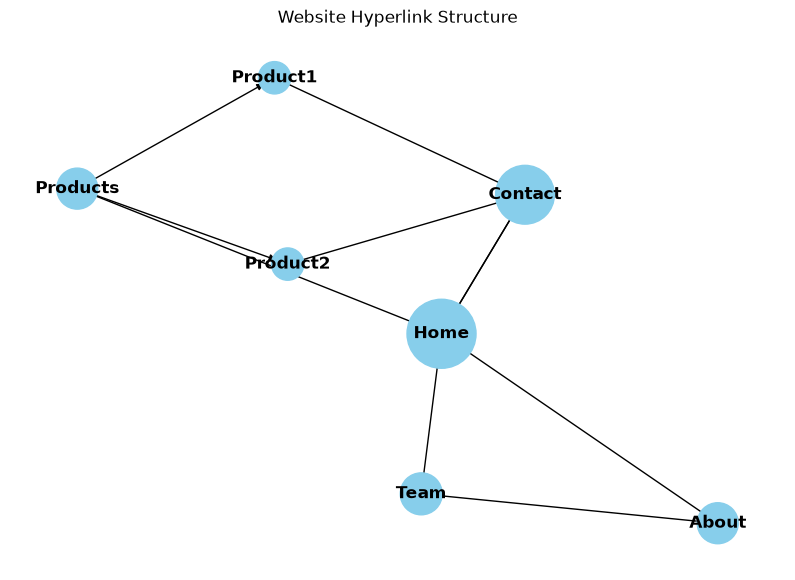

In [3]:
import networkx as nx 
import matplotlib.pyplot as plt 
graph = nx.DiGraph() 
edges = [ 
("Home", "About"), 
("Home", "Products"), 
("Home", "Contact"), 
("About", "Team"), 
("Products", "Product1"), 
("Products", "Product2"), 
("Product1", "Contact"), 
("Product2", "Contact"), 
("Team", "Home"), 
("Contact", "Home") 
]

graph.add_edges_from(edges) 
pagerank_scores = nx.pagerank(graph) 

sorted_pages = sorted( 
pagerank_scores.items(), 
key=lambda x: x[1], 
reverse=True 
)

print("Top Pages by PageRank\n") 
for page, score in sorted_pages: 
    print(f"{page:10} : {score:.4f}")

plt.figure(figsize=(10,7)) 
pos = nx.spring_layout(graph, seed=42) 
node_sizes = [ 
pagerank_scores[node] * 8000 
for node in graph.nodes() 
] 
nx.draw_networkx_nodes( 
graph, 
pos, 
node_color="skyblue", 
node_size=node_sizes 
) 
nx.draw_networkx_edges( 
graph, 
pos, 
arrows=True 
) 
nx.draw_networkx_labels( 
graph, 
pos, 
font_weight="bold" 
)

plt.title("Website Hyperlink Structure") 
plt.axis("off") 
plt.show()
